# Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
df=pd.read_csv('Employee.csv')
df.shape

(148, 6)

In [5]:
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


# Data Exploration

In [6]:
df.duplicated().sum()

np.int64(4)

In [7]:
df.drop_duplicates(inplace = True)
df.shape

(144, 6)

In [8]:
df.reset_index(inplace=True)
df.drop('index',axis=1,inplace=True)
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
139,Infosys Pvt Lmt,22.0,8202.0,Mumbai,India,0
140,TCS,33.0,9024.0,Calcutta,India,1
141,Infosys,44.0,4034.0,Delhi,India,1
142,TCS,33.0,5034.0,Mumbai,India,1


In [9]:
df.tail()

,Company,Age,Salary,Place,Country,Gender
139,Infosys Pvt Lmt,22.0,8202.0,Mumbai,India,0
140,TCS,33.0,9024.0,Calcutta,India,1
141,Infosys,44.0,4034.0,Delhi,India,1
142,TCS,33.0,5034.0,Mumbai,India,1
143,Infosys,22.0,8202.0,Cochin,India,0


In [10]:
df.describe()

,Age,Salary,Gender
count,127.000000,121.000000,144.000000
mean,30.527559,5283.471074,0.222222
std,11.114717,2585.373600,0.417191
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,33.000000,5000.000000,0.000000
75%,37.500000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  136 non-null    str    
 1   Age      127 non-null    float64
 2   Salary   121 non-null    float64
 3   Place    130 non-null    str    
 4   Country  144 non-null    str    
 5   Gender   144 non-null    int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 9.1 KB


In [12]:
#check for null in each column
df.isna().sum()

Company     8
Age        17
Salary     23
Place      14
Country     0
Gender      0
dtype: int64

In [13]:
df.columns

Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='str')

In [14]:
##Unique value in each columns
unique = df.nunique()
unique

Company     6
Age        29
Salary     40
Place      11
Country     1
Gender      2
dtype: int64

In [15]:
df['Company'].unique()

<ArrowStringArray>
[                      'TCS',                   'Infosys',
                       'CTS',                         nan,
 'Tata Consultancy Services',                'Congnizant',
           'Infosys Pvt Lmt']
Length: 7, dtype: str

In [16]:
df['Company'] = df['Company'].replace('Infosys Pvt Lmt', 'Infosys')
df['Company'] = df['Company'].replace('Tata Consultancy Services', 'TCS')
df['Company'] = df['Company'].replace('CTS', 'Cognizant')
df['Company'] = df['Company'].replace('Congnizant', 'Cognizant')

In [17]:
df['Age'].unique()

array([20., 30., 35., 40., 23., nan, 34., 45., 18., 22., 32., 37., 50.,
       21., 46., 36., 26., 41., 24., 25., 43., 19., 38., 51., 31., 44.,
       33., 17.,  0., 54.])

In [18]:
df['Salary'].unique()

array([  nan, 2300., 3000., 4000., 5000., 6000., 7000., 8000., 9000.,
       1089., 1234., 3030., 3045., 3184., 4824., 5835., 7084., 8943.,
       8345., 9284., 9876., 2034., 7654., 2934., 4034., 5034., 8202.,
       9024., 4345., 6544., 6543., 3234., 4324., 5435., 5555., 8787.,
       3454., 5654., 5009., 5098., 3033.])

In [19]:
df['Place'].unique()

<ArrowStringArray>
[   'Chennai',     'Mumbai',   'Calcutta',      'Delhi', 'Podicherry',
     'Cochin',          nan,      'Noida',  'Hyderabad',     'Bhopal',
     'Nagpur',       'Pune']
Length: 12, dtype: str

In [20]:
df.head(10)

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
5,Infosys,NaN,5000.0,Calcutta,India,0
6,TCS,NaN,6000.0,Chennai,India,1
7,Infosys,23.0,7000.0,Mumbai,India,1
8,TCS,34.0,8000.0,Calcutta,India,1
9,Cognizant,45.0,9000.0,Delhi,India,0


# Data Cleaning

In [21]:
df1=pd.read_csv('Employee.csv')


In [22]:
#Outlier detection in 'Age' column=IQR
q1=df['Age'].quantile(0.25)
q1

np.float64(22.0)

In [23]:
q3=df['Age'].quantile(0.75)
q3

np.float64(37.5)

In [24]:
iqr = q3-q1

In [25]:
lower=q1-1.5*iqr
lower

np.float64(-1.25)

In [26]:
upper=q3+1.5*iqr
upper

np.float64(60.75)

In [27]:
#outlier rows
df[(df['Age']<lower) & (df['Age']>upper)]
#no outliers detected using IQR. But Age=0 is an outlier.

,Company,Age,Salary,Place,Country,Gender


In [28]:
q1=df['Salary'].quantile(0.25)
q1

np.float64(3030.0)

In [29]:
q3=df['Salary'].quantile(0.75)
q3

np.float64(8000.0)

In [30]:
iqr=q3-q1
iqr

np.float64(4970.0)

In [31]:
lower=q1-1.5*iqr
lower

np.float64(-4425.0)

In [32]:
upper=q3+1.5*iqr
upper

np.float64(15455.0)

In [33]:
#outlier rows
df[(df['Salary']<lower) & (df['Salary']>upper)]
#no outliers detected using IQR.

,Company,Age,Salary,Place,Country,Gender


In [34]:
## For the 'Company' column we have rows with 'nan' values. It should be replacedby mode()-most repeated value, "TCS"
df['Company'].mode()[0]

'TCS'

In [35]:
df['Company'] = df['Company'].fillna(df['Company'].mode()[0])

In [36]:
df.isna().sum()

Company     0
Age        17
Salary     23
Place      14
Country     0
Gender      0
dtype: int64

In [37]:
df[df['Age']==0]

,Company,Age,Salary,Place,Country,Gender
87,Infosys,0.0,3030.0,Calcutta,India,0
91,TCS,0.0,3045.0,Delhi,India,0
100,Cognizant,0.0,2034.0,Podicherry,India,0
106,TCS,0.0,9024.0,Chennai,India,1
110,Infosys,0.0,3234.0,Mumbai,India,0
120,Cognizant,0.0,1234.0,Calcutta,India,0


In [38]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [39]:
df['Age'].isna().sum()

np.int64(0)

In [40]:
rounded_mean=round(df['Age'].mean(),0)
rounded_mean

np.float64(31.0)

In [41]:
df['Age'] = df['Age'].fillna(rounded_mean)

In [42]:
df.isna().sum()

Company     0
Age         0
Salary     23
Place      14
Country     0
Gender      0
dtype: int64

In [43]:
rounded_salary=round(df['Salary'].mean(),0)
rounded_salary

np.float64(5283.0)

In [44]:
df['Salary'] = df['Salary'].fillna(rounded_salary)

In [45]:
df.isna().sum()

Company     0
Age         0
Salary      0
Place      14
Country     0
Gender      0
dtype: int64

In [46]:
df['Place'] = df['Place'].fillna(df['Place'].mode()[0])

In [47]:
df.isna().sum()

Company    0
Age        0
Salary     0
Place      0
Country    0
Gender     0
dtype: int64

In [48]:
# Now the dataset df is cleaned 
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,5283.0,Chennai,India,0
1,Infosys,30.0,5283.0,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
139,Infosys,22.0,8202.0,Mumbai,India,0
140,TCS,33.0,9024.0,Calcutta,India,1
141,Infosys,44.0,4034.0,Delhi,India,1
142,TCS,33.0,5034.0,Mumbai,India,1


# Data Analysis

In [49]:
#Filter the data with age >40 and salary<5000
df[(df['Age']>40) & (df['Salary']<5000)]

,Company,Age,Salary,Place,Country,Gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
85,Infosys,41.0,3000.0,Delhi,India,0
92,Infosys,54.0,3184.0,Mumbai,India,0
103,Infosys,44.0,4034.0,Delhi,India,0


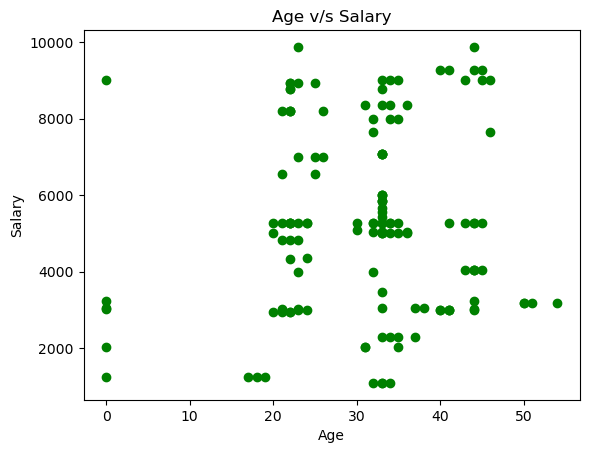

In [50]:
#Plot the chart with age and salary
#correlation between salary and age
plt.scatter(df['Age'],df['Salary'],color='g')
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age v/s Salary")
plt.show()

In [51]:
#Count the number of people from each place and represent it visually
df['Place'].value_counts()

Place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64

In [52]:
x=df['Place'].value_counts().index
x

Index(['Mumbai', 'Calcutta', 'Chennai', 'Delhi', 'Cochin', 'Noida',
       'Hyderabad', 'Podicherry', 'Pune', 'Bhopal', 'Nagpur'],
      dtype='str', name='Place')

In [53]:
y=df['Place'].value_counts().values
y

array([48, 32, 14, 14, 13,  8,  8,  3,  2,  1,  1])

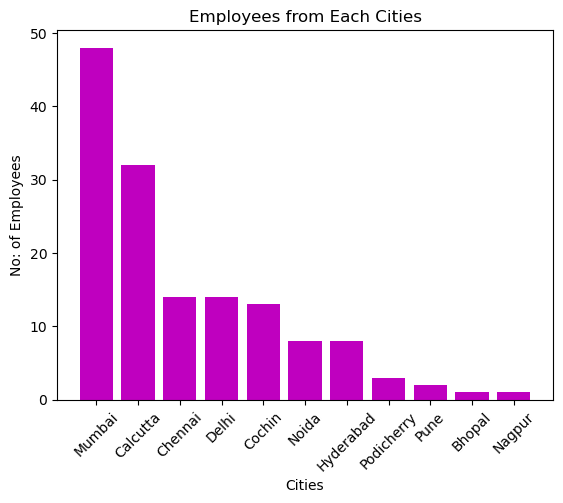

In [54]:
plt.bar(x,y,color='m')
plt.xlabel("Cities")
plt.ylabel("No: of Employees")
plt.title("Employees from Each Cities")
plt.xticks(rotation=45)
plt.show()

# Data Encoding

In [55]:
# the 'Gender' column is a 'Nominal categorical' column. so it couldn't be ranked like this.
# Assume M=0 & F=1
#categorical data encoding

In [56]:
df.head(1)

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,5283.0,Chennai,India,0


In [63]:
df['Gender'] = df['Gender'].replace({'M': 0, 'F': 1})

In [64]:
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,5283.0,Chennai,India,0
1,Infosys,30.0,5283.0,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [65]:
df['Gender'].value_counts()

Gender
0    112
1     32
Name: count, dtype: int64

In [66]:
df.describe()

,Age,Salary
count,144.000000,144.000000
mean,30.819444,5283.395833
std,10.463826,2368.350171
min,0.000000,1089.000000
25%,23.000000,3045.000000
50%,33.000000,5283.000000
75%,36.000000,7084.000000
max,54.000000,9876.000000


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  144 non-null    str    
 1   Age      144 non-null    float64
 2   Salary   144 non-null    float64
 3   Place    144 non-null    str    
 4   Country  144 non-null    str    
 5   Gender   144 non-null    object 
dtypes: float64(2), object(1), str(3)
memory usage: 9.3+ KB


In [68]:
# Here we have 4 categorical columns, "Company", "Place", "Country" & "Gender".
# Four of them are Nominal Categorical columns.
# since only one country's data is available,so we can skip the 'Country' column.

In [69]:
df.drop('Country',axis=1,inplace=True)
df

,Company,Age,Salary,Place,Gender
0,TCS,20.0,5283.0,Chennai,0
1,Infosys,30.0,5283.0,Mumbai,0
2,TCS,35.0,2300.0,Calcutta,0
3,Infosys,40.0,3000.0,Delhi,0
4,TCS,23.0,4000.0,Mumbai,0
...,...,...,...,...,...
139,Infosys,22.0,8202.0,Mumbai,0
140,TCS,33.0,9024.0,Calcutta,1
141,Infosys,44.0,4034.0,Delhi,1
142,TCS,33.0,5034.0,Mumbai,1


# OneHotEncoding

In [70]:
#Encoding Categorical datas using OneHotEncoding


In [71]:
df['Company'].unique()

<ArrowStringArray>
['TCS', 'Infosys', 'Cognizant']
Length: 3, dtype: str

In [72]:
df['Place'].unique()

<ArrowStringArray>
[   'Chennai',     'Mumbai',   'Calcutta',      'Delhi', 'Podicherry',
     'Cochin',      'Noida',  'Hyderabad',     'Bhopal',     'Nagpur',
       'Pune']
Length: 11, dtype: str

In [73]:
df['Gender'].unique()

array([0, 1], dtype=object)

In [74]:
#use 'OneHotEncoder' to create dummy variables for each of the nominal categorical columns.

In [75]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()

In [76]:
#dummies into an array
df_array=ohe.fit_transform(df[['Company','Place','Gender']]).toarray()
df_array

array([[0., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 1., 0.]], shape=(144, 16))

In [77]:
ohe.categories_

[array(['Cognizant', 'Infosys', 'TCS'], dtype=object),
 array(['Bhopal', 'Calcutta', 'Chennai', 'Cochin', 'Delhi', 'Hyderabad',
        'Mumbai', 'Nagpur', 'Noida', 'Podicherry', 'Pune'], dtype=object),
 array([0, 1], dtype=object)]

In [78]:
categories=[np.array(['Cognizant','Infosys','TCS']),
            np.array(['Bhopal','Calcutta','Chennai','Cochin','Delhi','Hyderabad','Mumbai','Nagpur','Noida','Pondicherry','Pune']),
            np.array(['F','M'])]


single_list=[innerlistone for main_array in categories for innerlistone in main_array]
single_list
#now it's in one list.

[np.str_('Cognizant'),
 np.str_('Infosys'),
 np.str_('TCS'),
 np.str_('Bhopal'),
 np.str_('Calcutta'),
 np.str_('Chennai'),
 np.str_('Cochin'),
 np.str_('Delhi'),
 np.str_('Hyderabad'),
 np.str_('Mumbai'),
 np.str_('Nagpur'),
 np.str_('Noida'),
 np.str_('Pondicherry'),
 np.str_('Pune'),
 np.str_('F'),
 np.str_('M')]

In [79]:
# create a dataset using the dummies array,'df_array' created using onehotencoder,
# use 'single_list' for column labelling.
df_new=pd.DataFrame(df_array,columns=single_list)
df_new

,Cognizant,Infosys,TCS,Bhopal,Calcutta,Chennai,Cochin,Delhi,Hyderabad,Mumbai,Nagpur,Noida,Pondicherry,Pune,F,M
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
140,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
141,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
142,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [80]:
#concat our dataset 'df' with 'df_new'

In [81]:
df_ml=pd.concat([df,df_new],axis=1)
df_ml

,Company,Age,Salary,Place,Gender,Cognizant,Infosys,TCS,Bhopal,Calcutta,...,Cochin,Delhi,Hyderabad,Mumbai,Nagpur,Noida,Pondicherry,Pune,F,M
0,TCS,20.0,5283.0,Chennai,0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Infosys,30.0,5283.0,Mumbai,0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,TCS,35.0,2300.0,Calcutta,0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Infosys,40.0,3000.0,Delhi,0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,TCS,23.0,4000.0,Mumbai,0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,Infosys,22.0,8202.0,Mumbai,0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
140,TCS,33.0,9024.0,Calcutta,1,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
141,Infosys,44.0,4034.0,Delhi,1,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
142,TCS,33.0,5034.0,Mumbai,1,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


# LabelEncoder

In [82]:
# example for encoding using LabelEncoder

In [83]:
#save the cleaned dataset 'df' in external
df.to_csv('Employee_cleaned.csv',index=False)

In [84]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
print(label)

LabelEncoder()


In [85]:

df_sample=pd.read_csv('Employee_cleaned.csv')
df_sample['Company']=label.fit_transform(df_sample['Company'])
df_sample

,Company,Age,Salary,Place,Gender
0,2,20.0,5283.0,Chennai,0
1,1,30.0,5283.0,Mumbai,0
2,2,35.0,2300.0,Calcutta,0
3,1,40.0,3000.0,Delhi,0
4,2,23.0,4000.0,Mumbai,0
...,...,...,...,...,...
139,1,22.0,8202.0,Mumbai,0
140,2,33.0,9024.0,Calcutta,1
141,1,44.0,4034.0,Delhi,1
142,2,33.0,5034.0,Mumbai,1


# Feature Scaling

In [86]:
#all numerical columns in the dataset to be standardized before ML model generation
# here we have 'Age' and 'Salary' columns only.
#cleaned dataset
df

,Company,Age,Salary,Place,Gender
0,TCS,20.0,5283.0,Chennai,0
1,Infosys,30.0,5283.0,Mumbai,0
2,TCS,35.0,2300.0,Calcutta,0
3,Infosys,40.0,3000.0,Delhi,0
4,TCS,23.0,4000.0,Mumbai,0
...,...,...,...,...,...
139,Infosys,22.0,8202.0,Mumbai,0
140,TCS,33.0,9024.0,Calcutta,1
141,Infosys,44.0,4034.0,Delhi,1
142,TCS,33.0,5034.0,Mumbai,1


# StandardScaler

In [87]:
# using standard scale

In [88]:
data=df.iloc[ : ,[1,2]]
data

,Age,Salary
0,20.0,5283.0
1,30.0,5283.0
2,35.0,2300.0
3,40.0,3000.0
4,23.0,4000.0
...,...,...
139,22.0,8202.0
140,33.0,9024.0
141,44.0,4034.0
142,33.0,5034.0


In [89]:
#import libraries
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler().fit(data)
print(scaler)

StandardScaler()


In [90]:
#standardize the data
data_scaled=scaler.transform(data)
print(data_scaled)

[[-1.03759458e+00 -1.67718000e-04]
 [-7.85854687e-02 -1.67718000e-04]
 [ 4.00919086e-01 -1.26409057e+00]
 [ 8.80423641e-01 -9.67494526e-01]
 [-7.49891845e-01 -5.43785893e-01]
 [ 2.09117264e-01 -1.20077261e-01]
 [ 2.09117264e-01  3.03631371e-01]
 [-7.49891845e-01  7.27340004e-01]
 [ 3.05018175e-01  1.15104864e+00]
 [ 1.35992820e+00  1.57475727e+00]
 [-7.49891845e-01 -1.67718000e-04]
 [ 3.05018175e-01 -1.77720172e+00]
 [ 1.35992820e+00 -1.67718000e-04]
 [-1.22939640e+00 -1.71576397e+00]
 [ 8.80423641e-01 -9.67494526e-01]
 [-7.49891845e-01 -9.67494526e-01]
 [-7.49891845e-01 -9.54783267e-01]
 [ 3.05018175e-01 -1.20077261e-01]
 [-8.45792756e-01 -1.67718000e-04]
 [ 1.13216353e-01 -1.67718000e-04]
 [ 5.92720908e-01 -9.48427637e-01]
 [ 1.83943275e+00 -8.89532137e-01]
 [-9.41693667e-01 -1.94649980e-01]
 [ 2.09117264e-01  2.33719447e-01]
 [ 2.09117264e-01  7.62931529e-01]
 [-7.49891845e-01  1.55060588e+00]
 [ 3.05018175e-01  1.29722811e+00]
 [ 1.35992820e+00  1.69509052e+00]
 [-7.49891845e-01  1

In [91]:
#check the mean, for a standarzide data it's = 0 or near,
print(data_scaled.mean(axis=0))

[1.48029737e-16 1.03312420e-16]


In [92]:
#check the std, for a standarzide data it's = 1,
print(data_scaled.std(axis=0))

[1. 1.]


In [93]:
#convert it into dataframe-table format
scaled_data_set=pd.DataFrame(data_scaled,columns=data.columns)
scaled_data_set

,Age,Salary
0,-1.037595,-0.000168
1,-0.078585,-0.000168
2,0.400919,-1.264091
3,0.880424,-0.967495
4,-0.749892,-0.543786
...,...,...
139,-0.845793,1.236638
140,0.209117,1.584926
141,1.264027,-0.529380
142,0.209117,-0.105671


# MinMaxScaler

In [94]:
data=df.iloc[ : ,[1,2]]
data

,Age,Salary
0,20.0,5283.0
1,30.0,5283.0
2,35.0,2300.0
3,40.0,3000.0
4,23.0,4000.0
...,...,...
139,22.0,8202.0
140,33.0,9024.0
141,44.0,4034.0
142,33.0,5034.0


In [95]:
#import libraries
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler().fit(data)
print(scaler)

MinMaxScaler()


In [96]:
#check min and max
scaler.data_min_

array([   0., 1089.])

In [97]:
data.describe()

,Age,Salary
count,144.000000,144.000000
mean,30.819444,5283.395833
std,10.463826,2368.350171
min,0.000000,1089.000000
25%,23.000000,3045.000000
50%,33.000000,5283.000000
75%,36.000000,7084.000000
max,54.000000,9876.000000


In [98]:
#check feature range
scaler.feature_range

(0, 1)

In [100]:
#standardize the data
data_scaled_mm=scaler.transform(data)
print(data_scaled_mm)

[[0.37037037 0.47729601]
 [0.55555556 0.47729601]
 [0.64814815 0.13781723]
 [0.74074074 0.21748037]
 [0.42592593 0.33128485]
 [0.61111111 0.44508934]
 [0.61111111 0.55889382]
 [0.42592593 0.6726983 ]
 [0.62962963 0.78650279]
 [0.83333333 0.90030727]
 [0.42592593 0.47729601]
 [0.62962963 0.        ]
 [0.83333333 0.47729601]
 [0.33333333 0.01650165]
 [0.74074074 0.21748037]
 [0.42592593 0.21748037]
 [0.42592593 0.2208945 ]
 [0.62962963 0.44508934]
 [0.40740741 0.47729601]
 [0.59259259 0.47729601]
 [0.68518519 0.22260157]
 [0.92592593 0.23842039]
 [0.38888889 0.42505975]
 [0.61111111 0.54011608]
 [0.61111111 0.68225788]
 [0.42592593 0.89382042]
 [0.62962963 0.82576534]
 [0.83333333 0.93262775]
 [0.42592593 1.        ]
 [0.64814815 0.10754524]
 [0.85185185 0.74712644]
 [0.37037037 0.20996927]
 [0.83333333 0.33515421]
 [0.66666667 0.44895869]
 [0.48148148 0.80949129]
 [0.64814815 0.90303858]
 [0.59259259 0.47729601]
 [0.64814815 0.47729601]
 [0.62962963 0.13781723]
 [0.75925926 0.21748037]


In [101]:
#convert it into dataframe-table format
mm_scaled_data_set=pd.DataFrame(data_scaled_mm,columns=data.columns)
mm_scaled_data_set

,Age,Salary
0,0.370370,0.477296
1,0.555556,0.477296
2,0.648148,0.137817
3,0.740741,0.217480
4,0.425926,0.331285
...,...,...
139,0.407407,0.809491
140,0.611111,0.903039
141,0.814815,0.335154
142,0.611111,0.448959


In [ ]:
# The dataset is now completely preprocessed for Machine Learning Modeling 